# Medicare Advantage Enrollment Trends and State Concentration Analysis

## A State-Level Analysis with New York Comparison (2020-2025)

## Project Overview

This project analyzes Medicare Advantage enrollment trends across the United States between 2020 and 2025 using CMS Medicare enrollment data, with early 2026 data included for current trend observation.

The analysis focuses on Medicare Advantage concentration, enrollment growth, operational monitoring categories, and comparisons between New York and national enrollment trends.

Since I currently work at Healthfirst and my role involves processing enrollment-related activities, I wanted to focus this project on Medicare Advantage enrollment trends to better connect the analysis to real-world healthcare operations.

## Methodology

The analysis focused on state-level Medicare enrollment data between 2020 and 2025, with partial 2026 data reviewed separately for current trend observation.

Python and pandas were used for data cleaning, filtering, aggregation, and trend analysis. Medicare Advantage enrollment percentages were calculated by comparing Medicare Advantage enrollment totals to total Medicare enrollment within each state.

Additional analysis included Medicare Advantage concentration categorization, growth trend analysis, and comparisons between New York and national enrollment patterns.

## Dataset Overview

The dataset used in this project comes from the CMS Medicare Monthly Enrollment data files. The dataset contains Medicare enrollment information at the national, state, and county levels beginning in 2013.

For this analysis, state-level enrollment data from 2020 through 2026 was used, including information related to Medicare Advantage enrollment, Original Medicare enrollment, dual-eligible beneficiaries, and Part D enrollment.


## Import Libraries and Load Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Medicare Monthly Enrollment Data_February 2026.csv")

## Initial Dataset Review


The dataset was reviewed to better understand its structure, available columns, and enrollment information included in the file. This step helps identify which variables are most relevant for Medicare Advantage enrollment trend analysis and operational monitoring concepts.

In [ ]:
df.head()

,YEAR,MONTH,BENE_GEO_LVL,BENE_STATE_ABRVTN,BENE_STATE_DESC,BENE_COUNTY_DESC,BENE_FIPS_CD,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,...,B_TOT_BENES,B_ORGNL_MDCR_BENES,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES
0,2013,Year,National,US,National,Total,,52425659,37613096,14812563,...,47959444,33147099,14812345,35679758,22661451,13018307,10000861,1030113.0,409204.0,24239580
1,2013,Year,State,AL,Alabama,Total,01,921477.0,711448.0,210029.0,...,862992.0,652965.0,210026.0,637247.0,437749.0,199498.0,205496.0,32790.0,11452.0,387510.0
2,2013,Year,County,AL,Alabama,Autauga County,01001,9323.0,6484.0,2840.0,...,8742.0,5902.0,2840.0,6036.0,3268.0,2767.0,1839.0,296.0,105.0,3796.0
3,2013,Year,County,AL,Alabama,Baldwin County,01003,41033.0,28775.0,12258.0,...,38651.0,26393.0,12258.0,27352.0,15593.0,11759.0,5276.0,867.0,379.0,20830.0
4,2013,Year,County,AL,Alabama,Barbour County,01005,5847.0,5036.0,810.0,...,5515.0,4704.0,810.0,4170.0,3410.0,759.0,1783.0,304.0,73.0,2009.0


In [ ]:
print(df.columns)

Index(['YEAR', 'MONTH', 'BENE_GEO_LVL', 'BENE_STATE_ABRVTN', 'BENE_STATE_DESC',
       'BENE_COUNTY_DESC', 'BENE_FIPS_CD', 'TOT_BENES', 'ORGNL_MDCR_BENES',
       'MA_AND_OTH_BENES', 'AGED_TOT_BENES', 'AGED_ESRD_BENES',
       'AGED_NO_ESRD_BENES', 'DSBLD_TOT_BENES',
       'DSBLD_ESRD_AND_ESRD_ONLY_BENES', 'DSBLD_NO_ESRD_BENES',
       'MALE_TOT_BENES', 'FEMALE_TOT_BENES', 'WHITE_TOT_BENES',
       'BLACK_TOT_BENES', 'API_TOT_BENES', 'HSPNC_TOT_BENES',
       'NATIND_TOT_BENES', 'OTHR_TOT_BENES', 'AGE_LT_25_BENES',
       'AGE_25_TO_44_BENES', 'AGE_45_TO_64_BENES', 'AGE_65_TO_69_BENES',
       'AGE_70_TO_74_BENES', 'AGE_75_TO_79_BENES', 'AGE_80_TO_84_BENES',
       'AGE_85_TO_89_BENES', 'AGE_90_TO_94_BENES', 'AGE_GT_94_BENES',
       'DUAL_TOT_BENES', 'FULL_DUAL_TOT_BENES', 'PART_DUAL_TOT_BENES',
       'NODUAL_TOT_BENES', 'QMB_ONLY_BENES', 'QMB_PLUS_BENES',
       'SLMB_ONLY_BENES', 'SLMB_PLUS_BENES', 'QDWI_QI_BENES',
       'OTHR_FULL_DUAL_MDCD_BENES', 'A_B_TOT_BENES', 'A_B_ORGNL_MD

In [ ]:
print(df.shape)

(570432, 60)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 570432 entries, 0 to 570431
Data columns (total 60 columns):
 #   Column                                        Non-Null Count   Dtype 
---  ------                                        --------------   ----- 
 0   YEAR                                          570432 non-null  int64 
 1   MONTH                                         570432 non-null  object
 2   BENE_GEO_LVL                                  570432 non-null  object
 3   BENE_STATE_ABRVTN                             570432 non-null  object
 4   BENE_STATE_DESC                               570432 non-null  object
 5   BENE_COUNTY_DESC                              570432 non-null  object
 6   BENE_FIPS_CD                                  570432 non-null  object
 7   TOT_BENES                                     570432 non-null  object
 8   ORGNL_MDCR_BENES                              570432 non-null  object
 9   MA_AND_OTH_BENES                              570432 non-nu

## Filter State-Level Enrollment Data

The original CMS dataset includes national, state, and county-level Medicare enrollment records. For this project, I filtered the data to state-level records only so I can compare enrollment trends across states and include a focused comparison for New York.

I also selected the main columns needed for this analysis, including total Medicare beneficiaries, Original Medicare beneficiaries, Medicare Advantage beneficiaries, dual-eligible beneficiaries, and Part D beneficiaries.

In [ ]:
state_df = df[df["BENE_GEO_LVL"] == "State"].copy()

medicare_df = state_df.loc[:, ["YEAR","MONTH","BENE_STATE_DESC","TOT_BENES","ORGNL_MDCR_BENES","MA_AND_OTH_BENES","DUAL_TOT_BENES","PRSCRPTN_DRUG_TOT_BENES"]].copy()

medicare_df = medicare_df[medicare_df["YEAR"].between(2020, 2026)].copy()

medicare_df.head()


,YEAR,MONTH,BENE_STATE_DESC,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,DUAL_TOT_BENES,PRSCRPTN_DRUG_TOT_BENES
303499,2020,Year,Alabama,1062553.0,576678.0,485875.0,215804.0,784111.0
303568,2020,Year,Alaska,104458.0,102628.0,1830.0,18887.0,66925.0
303600,2020,Year,Arizona,1370052.0,787986.0,582065.0,234041.0,1033923.0
303617,2020,Year,Arkansas,646902.0,453927.0,192975.0,135994.0,470080.0
303694,2020,Year,California,6411023.0,3503816.0,2907207.0,1488721.0,5121503.0


## Data Cleaning and Preparation

After filtering the dataset to state-level records, I selected the columns most relevant to the analysis. The enrollment count fields were converted to numeric values so calculations could be performed correctly. I also created a new column called `MA_Percent`, which calculates the percentage of total Medicare beneficiaries enrolled in Medicare Advantage or other Medicare health plans.

In [ ]:
number_cols = ["TOT_BENES","ORGNL_MDCR_BENES","MA_AND_OTH_BENES","DUAL_TOT_BENES","PRSCRPTN_DRUG_TOT_BENES"]

medicare_df[number_cols] = medicare_df[number_cols].apply(pd.to_numeric, errors="coerce")

medicare_df["MA_Percent"] = (medicare_df["MA_AND_OTH_BENES"] / medicare_df["TOT_BENES"]) * 100

medicare_df["MA_Percent"] = medicare_df["MA_Percent"].round(2)

medicare_df.head()


,YEAR,MONTH,BENE_STATE_DESC,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,DUAL_TOT_BENES,PRSCRPTN_DRUG_TOT_BENES,MA_Percent
303499,2020,Year,Alabama,1062553.0,576678.0,485875.0,215804.0,784111.0,45.73
303568,2020,Year,Alaska,104458.0,102628.0,1830.0,18887.0,66925.0,1.75
303600,2020,Year,Arizona,1370052.0,787986.0,582065.0,234041.0,1033923.0,42.48
303617,2020,Year,Arkansas,646902.0,453927.0,192975.0,135994.0,470080.0,29.83
303694,2020,Year,California,6411023.0,3503816.0,2907207.0,1488721.0,5121503.0,45.35


In [ ]:
medicare_df["YEAR"].value_counts().sort_index()

,count
YEAR,
2020,754
2021,754
2022,754
2023,754
2024,754
2025,754
2026,116


## Medicare Advantage Enrollment Percentage Analysis

This section identifies states with the highest Medicare Advantage enrollment concentration between 2020 and 2025. Medicare Advantage concentration is calculated as the percentage of total Medicare beneficiaries enrolled in Medicare Advantage or other Medicare managed care plans.

Higher Medicare Advantage concentration may indicate increased managed care activity and greater operational complexity related to enrollment processing and member management.

In [ ]:
year_df = medicare_df[medicare_df["MONTH"] == "Year"].copy()

exclude = ["Puerto Rico", "Virgin Islands", "American Samoa", "Guam", "Northern Mariana Islands", "Foreign and Other Outlying Areas"]

year_states_df = year_df[~year_df["BENE_STATE_DESC"].isin(exclude)].copy()



In [ ]:
avg_ma_by_state = year_states_df.groupby("BENE_STATE_DESC")["MA_Percent"].mean().reset_index()

avg_ma_by_state["MA_Percent"] = (avg_ma_by_state["MA_Percent"]).round(2)


In [ ]:
top_avg_states = avg_ma_by_state.sort_values("MA_Percent", ascending=False).head(10)

display(top_avg_states)

,BENE_STATE_DESC,MA_Percent
22,Michigan,56.41
23,Minnesota,55.49
39,Rhode Island,54.81
0,Alabama,54.61
9,Florida,53.28
50,Wisconsin,52.84
35,Ohio,52.29
6,Connecticut,52.07
19,Maine,51.99
37,Oregon,51.64


The chart below shows the average Medicare Advantage enrollment percentage for each state between 2020 and 2025. The percentages were averaged across all full-year records to identify states that consistently maintained high Medicare Advantage enrollment concentration over time.

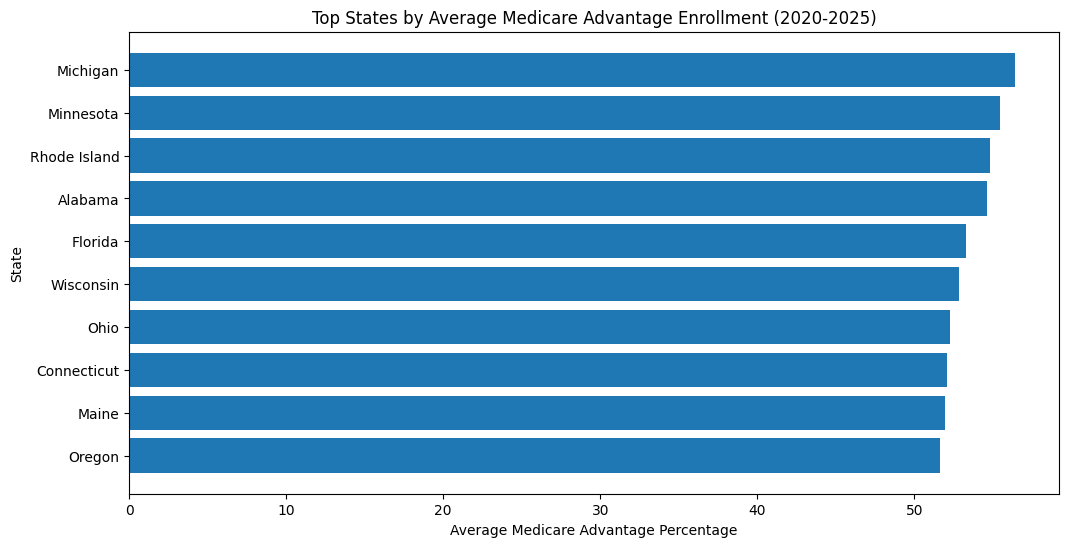

In [ ]:
plt.figure(figsize=(12,6))

plt.barh(top_avg_states["BENE_STATE_DESC"], top_avg_states["MA_Percent"])

plt.xlabel("Average Medicare Advantage Percentage")
plt.ylabel("State")
plt.title("Top States by Average Medicare Advantage Enrollment (2020-2025)")
plt.gca().invert_yaxis()

plt.show()

## Medicare Advantage Concentration Categories

This section categorizes states based on average Medicare Advantage enrollment concentration between 2020 and 2025. Medicare Advantage concentration refers to the percentage of Medicare beneficiaries within a state who are enrolled in Medicare Advantage or other Medicare managed care plans instead of Original Medicare.

The concentration categories were created to group states based on overall Medicare Advantage participation levels. States with higher Medicare Advantage concentration may indicate stronger managed care penetration and increased enrollment-related operational activity.

States with higher Medicare Advantage concentration may experience increased operational activity related to:

- Enrollment processing and plan selection changes
- Member eligibility verification
- Coordination between Medicare and managed care organizations
- Reconciliation of enrollment records
- Increased customer service and member support demands
- Oversight of enrollment accuracy and reporting requirements

The analysis also compares New York to other states to better understand how Medicare Advantage participation in New York aligns with national enrollment patterns and managed care activity levels.

In [ ]:
def concentration_level(ma_percent):
    if ma_percent >= 45:
        return "High MA Concentration"
    elif ma_percent >= 30:
        return "Moderate MA Concentration"
    else:
        return "Low MA Concentration"

In [ ]:
avg_ma_by_state["Concentration_Level"] = (avg_ma_by_state["MA_Percent"].apply(concentration_level))

In [ ]:
ny_concentration = avg_ma_by_state[avg_ma_by_state["BENE_STATE_DESC"] == "New York"]

display(ny_concentration)

,BENE_STATE_DESC,MA_Percent,Concentration_Level
32,New York,48.89,High MA Concentration


In [ ]:
concentration_counts = avg_ma_by_state["Concentration_Level"].value_counts()

display(concentration_counts)

,count
Concentration_Level,
High MA Concentration,27
Moderate MA Concentration,14
Low MA Concentration,11


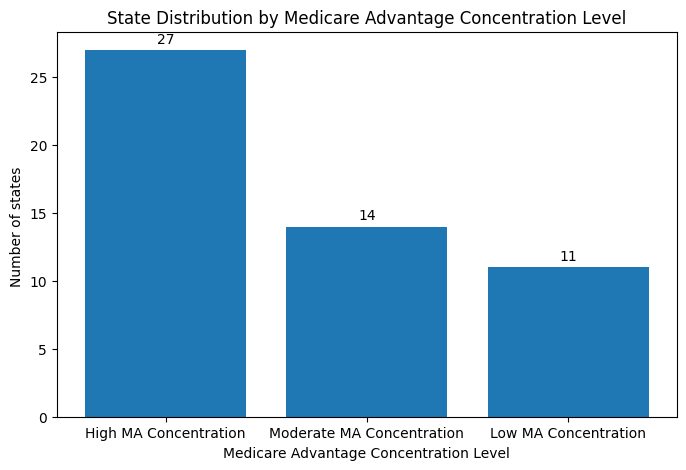

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(concentration_counts.index,concentration_counts.values)

plt.xlabel("Medicare Advantage Concentration Level")
plt.ylabel("Number of states ")
plt.title("State Distribution by Medicare Advantage Concentration Level")

for i, value in enumerate(concentration_counts.values):plt.text(i, value + 0.5, str(value), ha='center')

plt.show()

### New York Compared to Top Medicare Advantage States

The chart below compares New York’s average Medicare Advantage concentration to several of the highest Medicare Advantage concentration states between 2020 and 2025.

This comparison helps show how New York aligns with some of the strongest Medicare Advantage markets in the country and provides additional operational context related to managed care participation and enrollment activity.

In [ ]:
top5_states = avg_ma_by_state.sort_values("MA_Percent",ascending=False).head(5)

ny_state = avg_ma_by_state[avg_ma_by_state["BENE_STATE_DESC"] == "New York"]

comparison_df = pd.concat([top5_states, ny_state]).drop_duplicates()

display(comparison_df[["BENE_STATE_DESC", "MA_Percent"]])

,BENE_STATE_DESC,MA_Percent
22,Michigan,56.41
23,Minnesota,55.49
39,Rhode Island,54.81
0,Alabama,54.61
9,Florida,53.28
32,New York,48.89


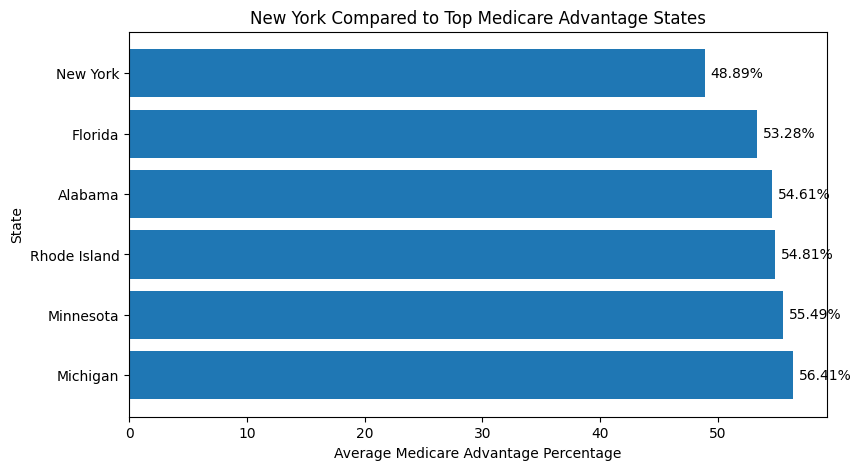

In [ ]:
plt.figure(figsize=(9,5))

plt.barh(comparison_df["BENE_STATE_DESC"],comparison_df["MA_Percent"])

plt.xlabel("Average Medicare Advantage Percentage")
plt.ylabel("State")

plt.title("New York Compared to Top Medicare Advantage States")

for i, value in enumerate(comparison_df["MA_Percent"]):
    plt.text(value + 0.5,i,f"{value:.2f}%",va='center')

plt.show()

## Multi-Year Comparison of Top Medicare Advantage States

This section compares yearly Medicare Advantage enrollment percentages between New York and several of the highest Medicare Advantage concentration states between 2020 and 2025.

The goal of this analysis is to evaluate how Medicare Advantage participation changed over time across major managed care markets and to compare New York’s long-term trend performance against other leading states.

In [ ]:
comparison_states = ["Michigan","Minnesota","Rhode Island","Alabama","Florida","New York"]

yearly_comparison = year_df[year_df["BENE_STATE_DESC"].isin(comparison_states)].copy()

display(yearly_comparison[["YEAR", "BENE_STATE_DESC", "MA_Percent"]].head())

,YEAR,BENE_STATE_DESC,MA_Percent
303499,2020,Alabama,45.73
303838,2020,Florida,48.47
304775,2020,Michigan,47.79
304860,2020,Minnesota,48.40
305392,2020,New York,43.65


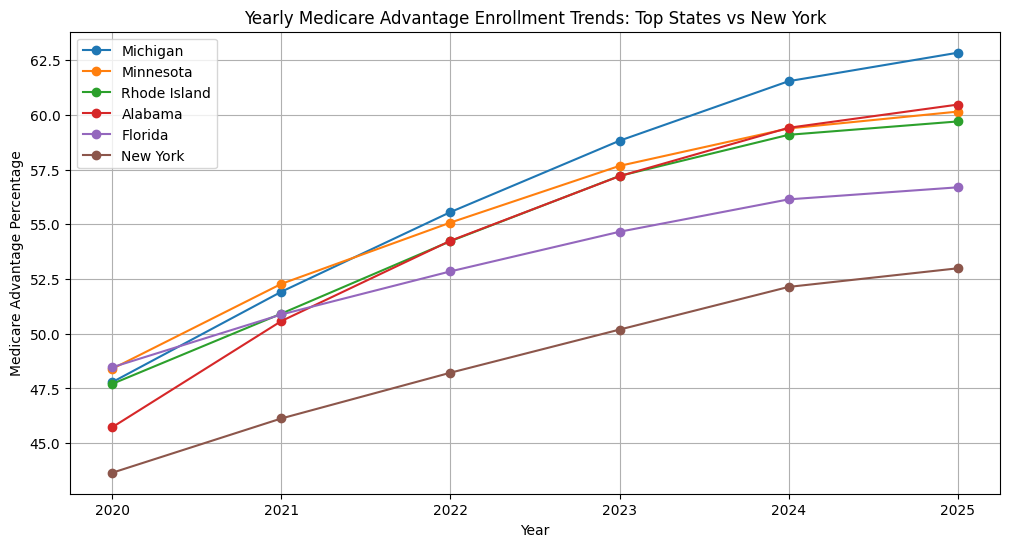

In [ ]:
plt.figure(figsize=(12,6))

for state in comparison_states:

    state_data = yearly_comparison[yearly_comparison["BENE_STATE_DESC"] == state]

    plt.plot(state_data["YEAR"],state_data["MA_Percent"],marker="o",label=state)

plt.xlabel("Year")
plt.ylabel("Medicare Advantage Percentage")

plt.title("Yearly Medicare Advantage Enrollment Trends: Top States vs New York")

plt.legend()

plt.grid(True)

plt.show()

## Multi-Year Enrollment Trend Analysis

This section analyzes national Medicare Advantage enrollment trends between 2020 and 2025 using yearly Medicare enrollment data.

The goal of this analysis is to identify long-term Medicare Advantage enrollment patterns and evaluate how managed care participation has changed over time across the United States.

In [ ]:
national_yearly = medicare_df[(medicare_df["MONTH"] == "Year") & (medicare_df["BENE_STATE_DESC"] != "National")].copy()

In [ ]:
yearly_trends = national_yearly.groupby("YEAR")["MA_AND_OTH_BENES"].sum().reset_index()

display(yearly_trends)


,YEAR,MA_AND_OTH_BENES
0,2020,25063916.0
1,2021,27536237.0
2,2022,29829618.0
3,2023,32142153.0
4,2024,34081255.0
5,2025,35344844.0


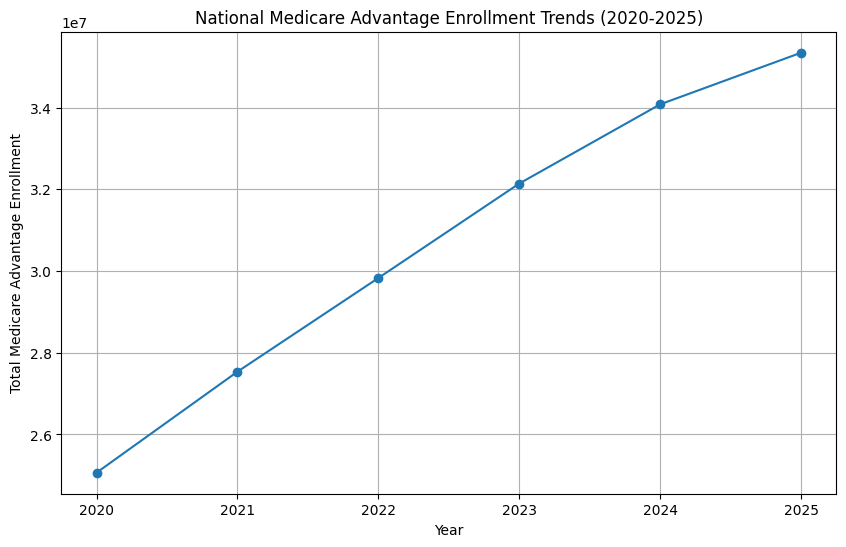

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(yearly_trends["YEAR"], yearly_trends["MA_AND_OTH_BENES"], marker="o")

plt.xlabel("Year")
plt.ylabel("Total Medicare Advantage Enrollment")
plt.title("National Medicare Advantage Enrollment Trends (2020-2025)")
plt.grid(True)
plt.show()

## 2026 Year-to-Date Enrollment Snapshot

Early 2026 Medicare Advantage enrollment data showed relatively stable enrollment activity between January and February 2026. Since only partial-year data is currently available, the 2026 results were reviewed as a preliminary enrollment snapshot rather than a full trend analysis.

The early 2026 data generally remained consistent with the broader long-term Medicare Advantage growth trends identified throughout the project.

In [ ]:
snapshot_2026 = medicare_df[medicare_df["YEAR"] == 2026].copy()

display(snapshot_2026.head())

,YEAR,MONTH,BENE_STATE_DESC,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,DUAL_TOT_BENES,PRSCRPTN_DRUG_TOT_BENES,MA_Percent
563759,2026,January,Alabama,1138249.0,441862.0,696387.0,225036.0,911177.0,61.18
563828,2026,January,Alaska,122547.0,119142.0,3405.0,18631.0,83450.0,2.78
563860,2026,January,Arizona,1549031.0,753614.0,795417.0,251421.0,1252656.0,51.35
563877,2026,January,Arkansas,690446.0,366651.0,323795.0,133119.0,551981.0,46.90
563954,2026,January,California,7177800.0,3496246.0,3681554.0,1819137.0,6040336.0,51.29


In [ ]:
snapshot_2026["MONTH"].value_counts()

,count
MONTH,
January,58
February,58


In [ ]:
national_2026 = snapshot_2026.groupby("MONTH")["MA_AND_OTH_BENES"].sum().reset_index()

display(national_2026)

,MONTH,MA_AND_OTH_BENES
0,February,35873219.0
1,January,35714064.0


## Year-over-Year Growth Analysis

This section evaluates Medicare Advantage enrollment growth between 2020 and 2025. The analysis focuses on identifying states with the largest percentage increases in Medicare Advantage enrollment over time.

Understanding enrollment growth trends may help support operational monitoring by identifying areas with increasing managed care activity and expanding enrollment volumes.

In [ ]:
growth_df = year_states_df.pivot_table(index="BENE_STATE_DESC",columns="YEAR",values="MA_AND_OTH_BENES")

growth_df = growth_df[growth_df[2020] != 0].copy()

growth_df["Growth_Percent"] = ((growth_df[2025] - growth_df[2020]) / growth_df[2020]) * 100

growth_df["Growth_Percent"] = growth_df["Growth_Percent"].round(2)

In [ ]:
growth_filtered = growth_df[growth_df[2025] >= 500000].copy()

top_growth_states = growth_filtered.sort_values("Growth_Percent",ascending=False).head(10)

In [ ]:
top_growth_table = top_growth_states.reset_index()[["BENE_STATE_DESC", "Growth_Percent"]].copy()

top_growth_table.columns.name = None

display(top_growth_table)

,BENE_STATE_DESC,Growth_Percent
0,Virginia,73.75
1,South Carolina,58.34
2,North Carolina,57.59
3,Illinois,56.02
4,Indiana,53.58
5,Washington,50.41
6,Kentucky,49.58
7,Massachusetts,47.35
8,Missouri,45.75
9,Louisiana,45.74


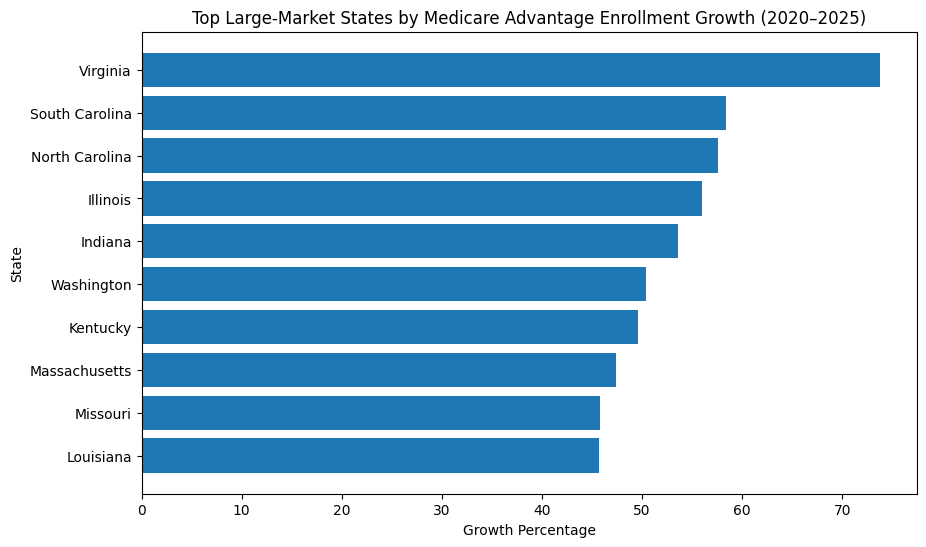

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(top_growth_states.reset_index()["BENE_STATE_DESC"],top_growth_states["Growth_Percent"])

plt.xlabel("Growth Percentage")
plt.ylabel("State")
plt.title("Top Large-Market States by Medicare Advantage Enrollment Growth (2020–2025)")

plt.gca().invert_yaxis()

plt.show()

## New York Comparison Analysis

This section compares New York Medicare Advantage enrollment trends against national enrollment patterns and other high-growth states. Since the project focuses on healthcare enrollment operations, comparing New York to national trends helps provide additional operational context related to Medicare Advantage growth and managed care activity.

In [ ]:
national_avg = year_states_df.groupby("YEAR")["MA_Percent"].mean().reset_index()

In [ ]:
ny_df = year_states_df[year_states_df["BENE_STATE_DESC"] == "New York"].copy()

display(ny_df[["YEAR","TOT_BENES","MA_AND_OTH_BENES","MA_Percent"]])

,YEAR,TOT_BENES,MA_AND_OTH_BENES,MA_Percent
305392,2020,3672489.0,1602984.0,43.65
348760,2021,3705546.0,1709370.0,46.13
392129,2022,3761501.0,1813624.0,48.22
435510,2023,3832616.0,1923680.0,50.19
478891,2024,3914782.0,2041281.0,52.14
522272,2025,3990696.0,2114744.0,52.99


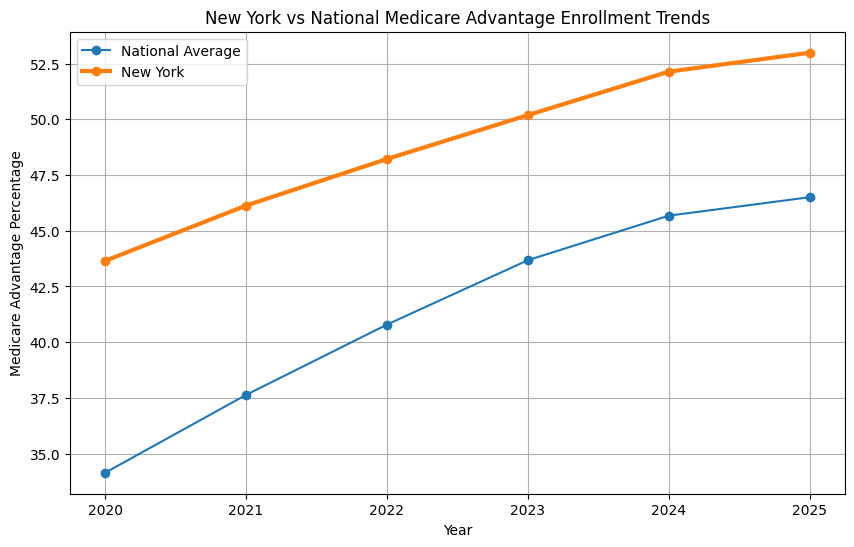

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(national_avg["YEAR"],national_avg["MA_Percent"],marker="o",label="National Average")

plt.plot(ny_df["YEAR"],ny_df["MA_Percent"],marker="o", linewidth=3,label="New York")

plt.xlabel("Year")
plt.ylabel("Medicare Advantage Percentage")
plt.title("New York vs National Medicare Advantage Enrollment Trends")
plt.legend()
plt.grid(True)
plt.show()

## Operational Insights

Several important trends were identified during the analysis of Medicare Advantage enrollment data between 2020 and 2025.

Medicare Advantage enrollment continued to increase nationally throughout the
analysis period, showing steady growth in managed care participation.

States such as Michigan, Minnesota, Rhode Island, Alabama, and Florida maintained some of the highest average Medicare Advantage concentration levels during the study period.

The Medicare Advantage concentration analysis showed that many states fall within moderate or high concentration levels, which may indicate increased managed care participation and higher levels of enrollment-related operational activity.

States with higher Medicare Advantage concentration may experience increased operational activity related to enrollment processing, eligibility verification, reconciliation activities, member support, and managed care oversight.

Among larger Medicare Advantage markets, states such as Virginia, South Carolina, North Carolina, and Illinois experienced some of the strongest enrollment increases between 2020 and 2025.

New York consistently remained above the national average in Medicare Advantage enrollment percentage, suggesting strong managed care participation and continued enrollment activity within the state.

Early 2026 enrollment data continued to show ongoing Medicare Advantage activity, supporting the broader long-term trends observed throughout the analysis period.

These findings may help support healthcare operations analysis by identifying areas with increasing Medicare Advantage participation and long-term enrollment trend activity.


## Conclusion

This project analyzed Medicare Advantage enrollment trends across the United States using CMS Medicare enrollment data from 2020 through 2025.

The analysis identified continued growth in Medicare Advantage participation across many states, with several states maintaining high Medicare Advantage concentration levels over time. Growth analysis also showed strong enrollment expansion among several larger Medicare Advantage markets.

New York consistently remained above the national average in Medicare Advantage concentration throughout the analysis period, suggesting strong managed care participation and continued enrollment activity within the state.

The project also explored how Medicare Advantage concentration may relate to operational activity such as enrollment processing, eligibility verification, member support, and managed care oversight.

Overall, the analysis demonstrates how healthcare enrollment data can be used to support operational monitoring, identify enrollment trends, and better understand changes in Medicare Advantage participation across different geographic regions.


## Export Final Datasets for Tableu

In [ ]:
yearly_comparison.to_csv("yearly_comparison.csv",index=False)

In [ ]:
avg_ma_by_state.to_csv("ma_concentration_analysis.csv",index=False)

In [ ]:
top_growth_states.reset_index().to_csv("top_growth_states.csv",index=False)

In [ ]:
national_avg.to_csv("national_trends.csv",index=False)